In [3]:
library(hdf5r)
library(Seurat)
library(ggplot2)
library(stringr)
#####feature plot
library(Seurat)
library(ggplot2)
library(cowplot)
library(dplyr)
library(tidyr)
library(stringr)
library(viridis)
library(reshape2)
library(patchwork)
library(ggplot2)
library(ggridges)
library(RColorBrewer)
library(scales)
library("circlize")
library(ComplexHeatmap)
library(ggplot2)
library(reshape2)

In [4]:
setwd("/DATA/User/liqian7/pienapple/24AS_fig_add/11S5_update/")

In [5]:
sp <- readRDS("hs_macro_mono_layer_pseudobulk.RDS")

In [6]:
sp <- NormalizeData(sp)

In [8]:
expr <- FetchData(sp, vars = c("FN1", "MMP12", "MMP9"))

In [9]:
mer <- merge(sp@meta.data,expr,all = TRUE,by = 0)
rownames(mer) <- mer$Row.names
mer <- mer[,-1]

In [10]:
cols5 <- c('stage1'='#a7d3d4','stage2'='#009b9e','stage3'='#e4c1d9','stage4'='#c75dab')

In [11]:
mer1 <- mer[which(mer$sample_filter!="filter"),]
head(mer1)

,orig.ident,nCount_RNA,nFeature_RNA,sample,chip_id,layer,stage_ann,sample_filter,stage_ann_peaks,level,ns_stage,ns_stage_peak,as_stage,adventitia,stage_clinical,FN1,MMP12,MMP9
,<fct>,<dbl>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
A05872E5_1_1,A05872E5,4442,2154,A05872E5_1_1,A05872E5_1,1,stage3,save,stage3,good,stage1,stage2,stage2,none,late,3.548714,1.179036,2.8189156
A05872E5_1_10,A05872E5,7161,2912,A05872E5_1_10,A05872E5_1,10,stage3,save,stage3,good,stage1,stage2,stage2,none,late,3.881139,0.000000,0.8739897
A05872E5_1_100,A05872E5,3779,2030,A05872E5_1_100,A05872E5_1,100,stage3,save,stage3,good,stage1,stage2,stage2,none,late,3.211482,0.000000,0.0000000
A05872E5_1_11,A05872E5,8387,3069,A05872E5_1_11,A05872E5_1,11,stage3,save,stage3,good,stage1,stage2,stage2,none,late,2.873141,0.000000,0.0000000
A05872E5_1_12,A05872E5,8818,3235,A05872E5_1_12,A05872E5_1,12,stage3,save,stage3,good,stage1,stage2,stage2,none,late,4.400813,0.000000,2.8259290
A05872E5_1_13,A05872E5,7549,2928,A05872E5_1_13,A05872E5_1,13,stage3,save,stage3,good,stage1,stage2,stage2,none,late,4.082371,0.000000,1.6042316


In [12]:
# mer1$layer <-abs(mer1$layer-100)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


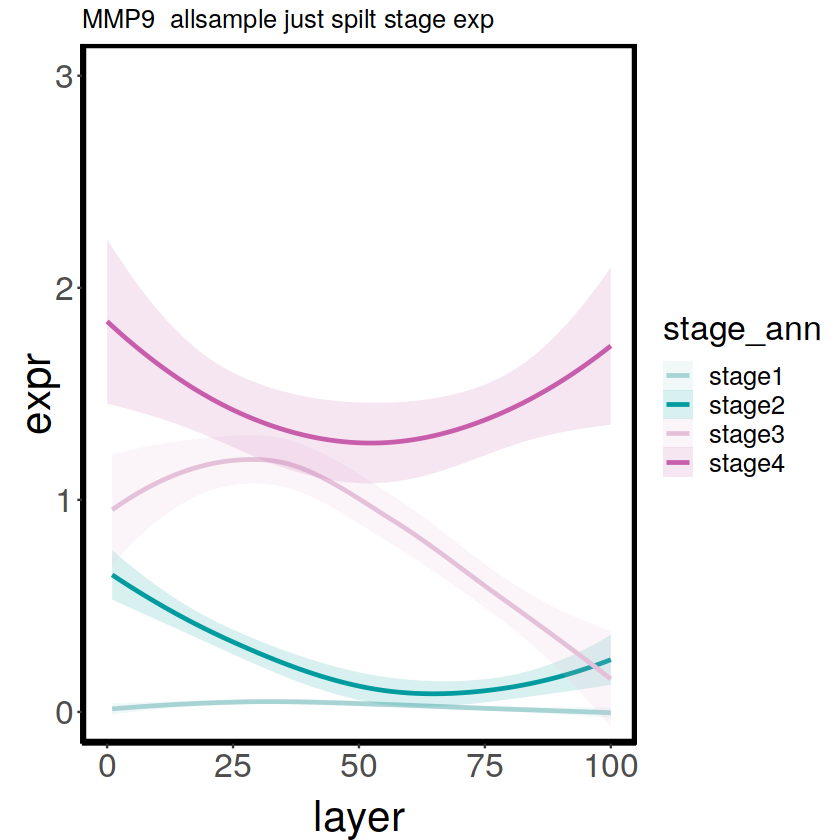

`geom_smooth()` using formula = 'y ~ x'


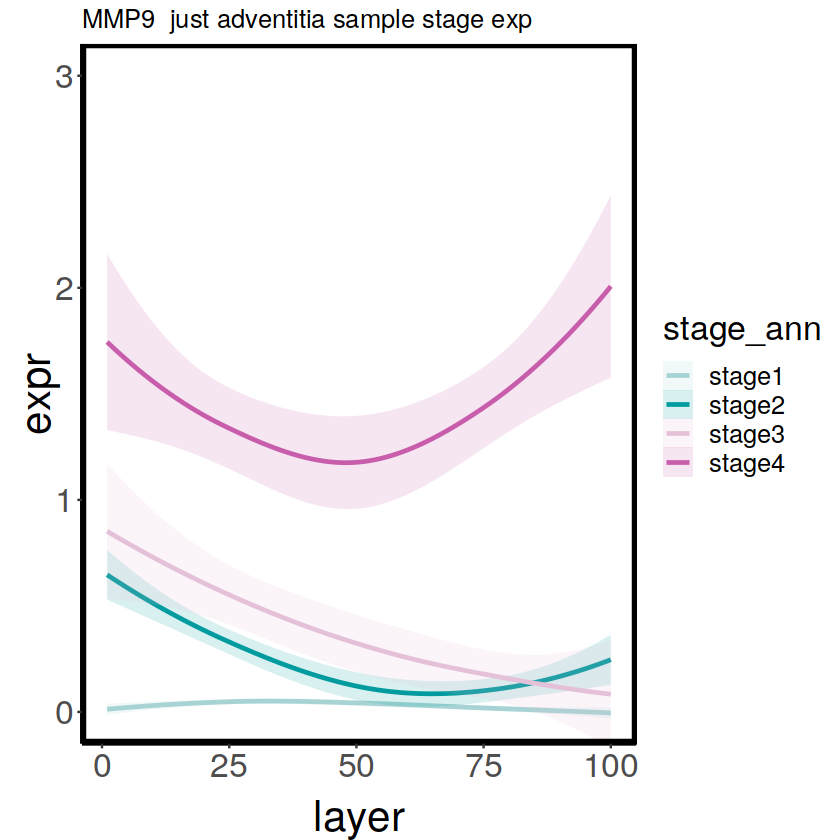

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


png 
  2

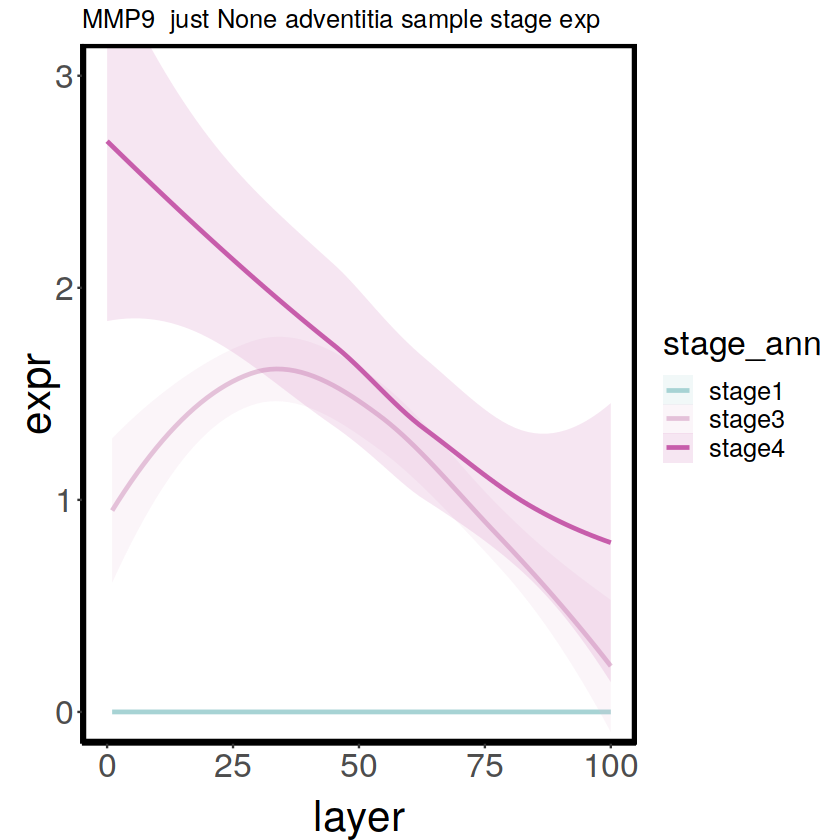

In [15]:
gene <- "MMP9"
p1<- ggplot(mer1,aes(x=layer,y = get(gene),fill=stage_ann,color=stage_ann))+theme_classic ()+
labs(subtitle = gene)+geom_smooth(method = "loess",span=1.5,se = T,level=0.9,alpha=0.15)+scale_fill_manual(values =cols5)+scale_color_manual(values = cols5)+
labs(x="layer",y="expr")+theme_bw()+theme(panel.grid = element_blank())+
theme_classic()+theme(axis.text = element_text (size = 20))+
theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
theme(plot.title = element_text(size = 25, face = "bold"))+
theme(axis.line = element_line(color = "black",linewidth = 0.8))+
theme(legend.title = element_text(size=20),
      legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+coord_cartesian(ylim = c(0, 3))+
labs(subtitle = paste0(gene,"  allsample just spilt stage exp"))+theme(plot.subtitle = element_text(size = 15))
print(p1)
p2 <- ggplot(mer1[which(mer1$adventitia!="none"),],aes(x=layer,y = get(gene),fill=stage_ann,color=stage_ann))+theme_classic ()+
labs(subtitle = gene)+geom_smooth(method = "loess",span=1.5,se = T,level=0.9,alpha=0.15)+scale_fill_manual(values =cols5)+scale_color_manual(values = cols5)+
labs(x="layer",y="expr")+theme_bw()+theme(panel.grid = element_blank())+
theme_classic()+theme(axis.text = element_text (size = 20))+
theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
theme(plot.title = element_text(size = 25, face = "bold"))+
theme(axis.line = element_line(color = "black",linewidth = 0.8))+
theme(legend.title = element_text(size=20),
      legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+coord_cartesian(ylim = c(0, 3))+
labs(subtitle = paste0(gene,"  just adventitia sample stage exp"))+theme(plot.subtitle = element_text(size = 15))
print(p2)
p3 <- ggplot(mer1[which(mer1$adventitia=="none"),],aes(x=layer,y = get(gene),fill=stage_ann,color=stage_ann))+theme_classic ()+
labs(subtitle = gene)+geom_smooth(method = "loess",span=1.5,se = T,level=0.9,alpha=0.15)+scale_fill_manual(values =cols5)+scale_color_manual(values = cols5)+
labs(x="layer",y="expr")+theme_bw()+theme(panel.grid = element_blank())+
theme_classic()+theme(axis.text = element_text (size = 20))+
theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
theme(plot.title = element_text(size = 25, face = "bold"))+
theme(axis.line = element_line(color = "black",linewidth = 0.8))+
theme(legend.title = element_text(size=20),
      legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+coord_cartesian(ylim = c(0, 3))+
labs(subtitle = paste0(gene,"  just None adventitia sample stage exp"))+theme(plot.subtitle = element_text(size = 15))
print(p3)
pdf(paste0(gene,"_sample_tissue_stage.pdf"),width = 20,height = 6)
print(p1|p2|p3)
dev.off()

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


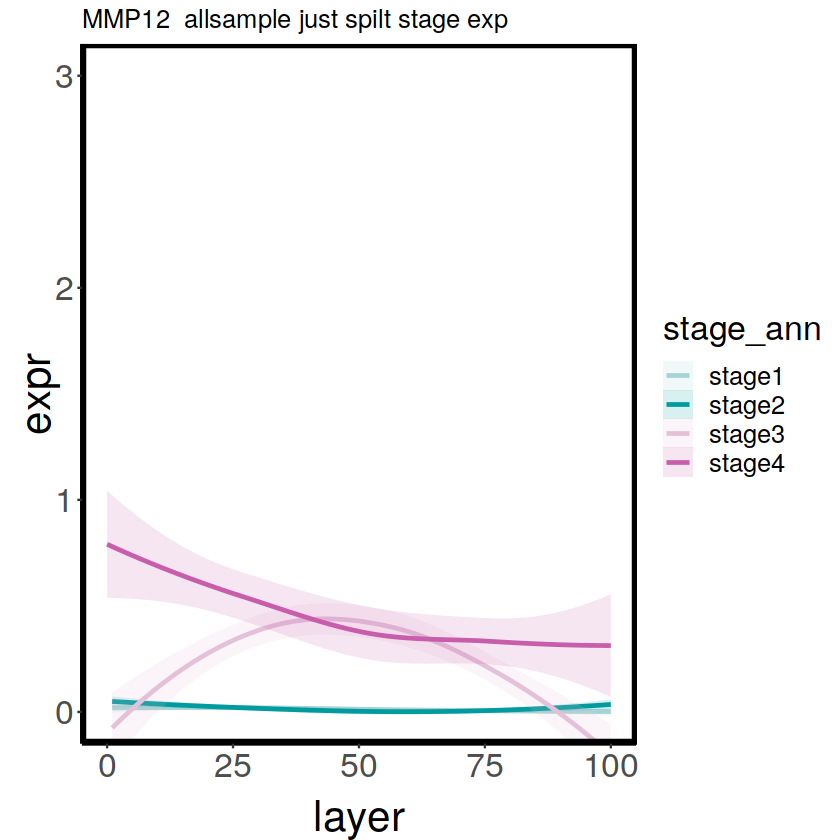

`geom_smooth()` using formula = 'y ~ x'


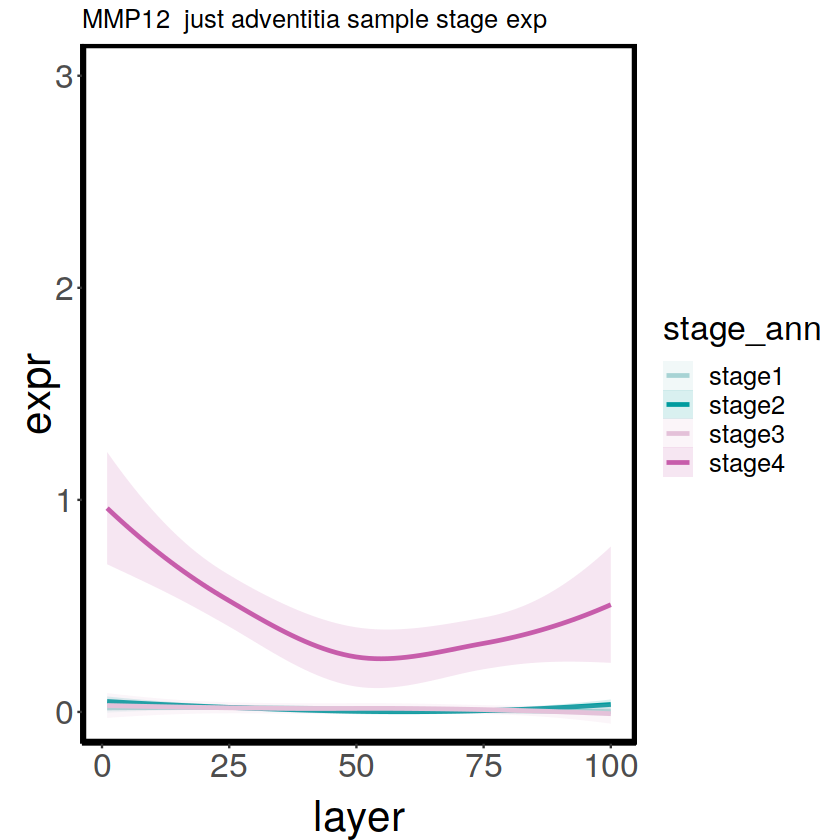

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


png 
  2

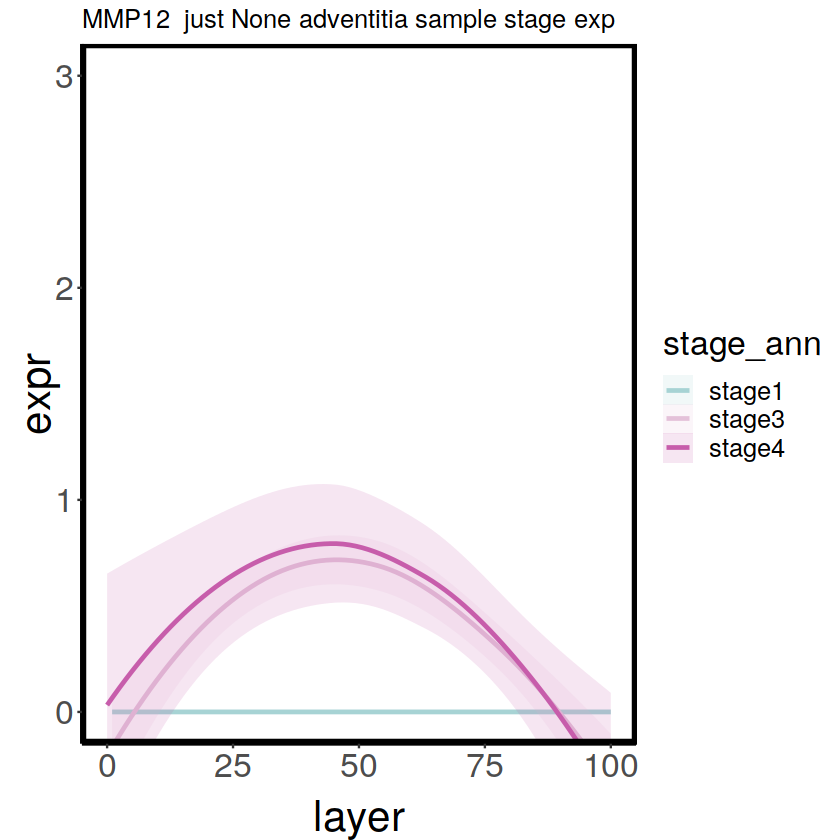

In [16]:
gene <- "MMP12"
p1<- ggplot(mer1,aes(x=layer,y = get(gene),fill=stage_ann,color=stage_ann))+theme_classic ()+
labs(subtitle = gene)+geom_smooth(method = "loess",span=1.5,se = T,level=0.95,alpha=0.15)+scale_fill_manual(values =cols5)+scale_color_manual(values = cols5)+
labs(x="layer",y="expr")+theme_bw()+theme(panel.grid = element_blank())+
theme_classic()+theme(axis.text = element_text (size = 20))+
theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
theme(plot.title = element_text(size = 25, face = "bold"))+
theme(axis.line = element_line(color = "black",linewidth = 0.8))+
theme(legend.title = element_text(size=20),
      legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+coord_cartesian(ylim = c(0, 3))+
labs(subtitle = paste0(gene,"  allsample just spilt stage exp"))+theme(plot.subtitle = element_text(size = 15))
print(p1)
p2 <- ggplot(mer1[which(mer1$adventitia!="none"),],aes(x=layer,y = get(gene),fill=stage_ann,color=stage_ann))+theme_classic ()+
labs(subtitle = gene)+geom_smooth(method = "loess",span=1.5,se = T,level=0.95,alpha=0.15)+scale_fill_manual(values =cols5)+scale_color_manual(values = cols5)+
labs(x="layer",y="expr")+theme_bw()+theme(panel.grid = element_blank())+
theme_classic()+theme(axis.text = element_text (size = 20))+
theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
theme(plot.title = element_text(size = 25, face = "bold"))+
theme(axis.line = element_line(color = "black",linewidth = 0.8))+
theme(legend.title = element_text(size=20),
      legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+coord_cartesian(ylim = c(0, 3))+
labs(subtitle = paste0(gene,"  just adventitia sample stage exp"))+theme(plot.subtitle = element_text(size = 15))
print(p2)
p3 <- ggplot(mer1[which(mer1$adventitia=="none"),],aes(x=layer,y = get(gene),fill=stage_ann,color=stage_ann))+theme_classic ()+
labs(subtitle = gene)+geom_smooth(method = "loess",span=1.5,se = T,level=0.95,alpha=0.15)+scale_fill_manual(values =cols5)+scale_color_manual(values = cols5)+
labs(x="layer",y="expr")+theme_bw()+theme(panel.grid = element_blank())+
theme_classic()+theme(axis.text = element_text (size = 20))+
theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
theme(plot.title = element_text(size = 25, face = "bold"))+
theme(axis.line = element_line(color = "black",linewidth = 0.8))+
theme(legend.title = element_text(size=20),
      legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+coord_cartesian(ylim = c(0, 3))+
labs(subtitle = paste0(gene,"  just None adventitia sample stage exp"))+theme(plot.subtitle = element_text(size = 15))
print(p3)
pdf(paste0(gene,"_sample_tissue_stage.pdf"),width = 20,height = 6)
print(p1|p2|p3)
dev.off()

In [17]:
sp <- readRDS("mm_macro_layer_pseudobulk.RDS")

In [18]:
sp <- NormalizeData(sp)

In [19]:
sp <- subset(sp,subset = nCount_RNA>200)

In [20]:
expr <- FetchData(sp, vars = c("Mmp12", "Mmp9"))

In [21]:
mer <- merge(sp@meta.data,expr,all = TRUE,by = 0)
rownames(mer) <- mer$Row.names
mer <- mer[,-1]

In [22]:
mer1 <- mer[which(mer$sample!="filter"),]
head(mer1)

,orig.ident,nCount_RNA,nFeature_RNA,sample,chip_id,layer,stage,chip,sample_filter,Mmp12,Mmp9
,<fct>,<dbl>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
SS200000005TL_F3_1_GC-AA_1,SS200000005TL,1371,660,SS200000005TL_F3_1_GC-AA_1,SS200000005TL_F3_1,1,stage1,SS200000005TL_F3,save,0.000000,0
SS200000005TL_F3_1_GC-AA_100,SS200000005TL,1601,613,SS200000005TL_F3_1_GC-AA_100,SS200000005TL_F3_1,100,stage1,SS200000005TL_F3,save,1.980463,0
SS200000005TL_F3_1_GC-AA_33,SS200000005TL,241,150,SS200000005TL_F3_1_GC-AA_33,SS200000005TL_F3_1,33,stage1,SS200000005TL_F3,save,0.000000,0
SS200000005TL_F3_1_GC-AA_54,SS200000005TL,286,134,SS200000005TL_F3_1_GC-AA_54,SS200000005TL_F3_1,54,stage1,SS200000005TL_F3,save,0.000000,0
SS200000005TL_F3_1_GC-AA_63,SS200000005TL,311,170,SS200000005TL_F3_1_GC-AA_63,SS200000005TL_F3_1,63,stage1,SS200000005TL_F3,save,0.000000,0
SS200000005TL_F3_1_GC-AA_81,SS200000005TL,530,263,SS200000005TL_F3_1_GC-AA_81,SS200000005TL_F3_1,81,stage1,SS200000005TL_F3,save,0.000000,0


In [23]:
# mer1$layer <- abs(mer1$layer-100)

In [24]:
m <- mer1[which(mer1$stage!="NA"),]

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


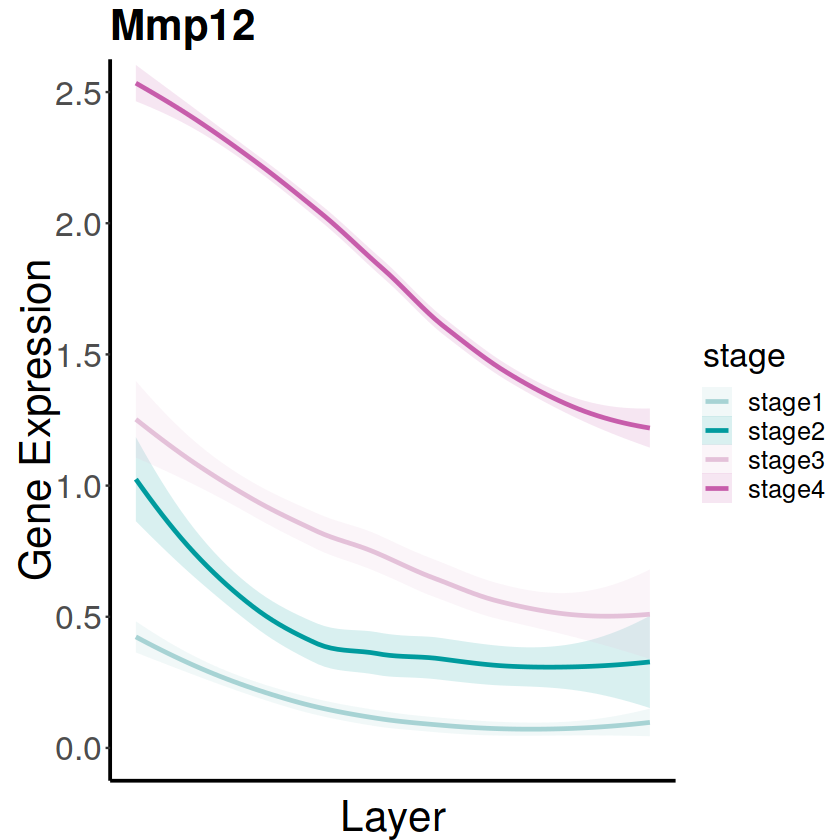

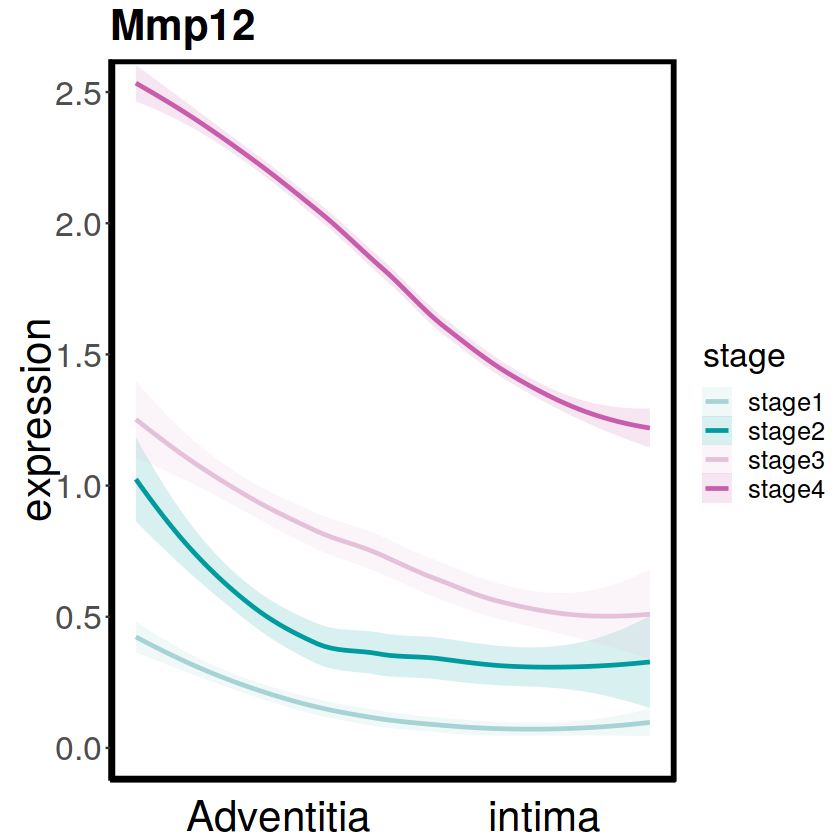

In [25]:
p <- ggplot(m,aes(x=layer,y = Mmp12,fill=stage,color=stage))+theme_classic ()+
labs(title = "Mmp12")+geom_smooth(method = "loess",span=1,se = T,level=0.90,alpha=0.15)+scale_color_manual(values = cols5)+scale_fill_manual(values = cols5)+
labs(x="Layer",y="Gene Expression")+theme(axis.text = element_text (size = 20))+#调整坐标轴字体大小
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+#调整xlab字体大小
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+#调整ylab字体大小
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+#调整坐标轴样式
    theme(legend.title = element_text(size=20),  # 调整图例标题的大小
          legend.text = element_text(size=15))+ theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank())+coord_cartesian(ylim = c(0, 2.5))
p
p2 <- p+labs(x="Adventitia          intima",y="expression")+theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))
ggsave("update_S5_Mmp12.pdf",p2,width = 6.6,height = 6)
p2

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


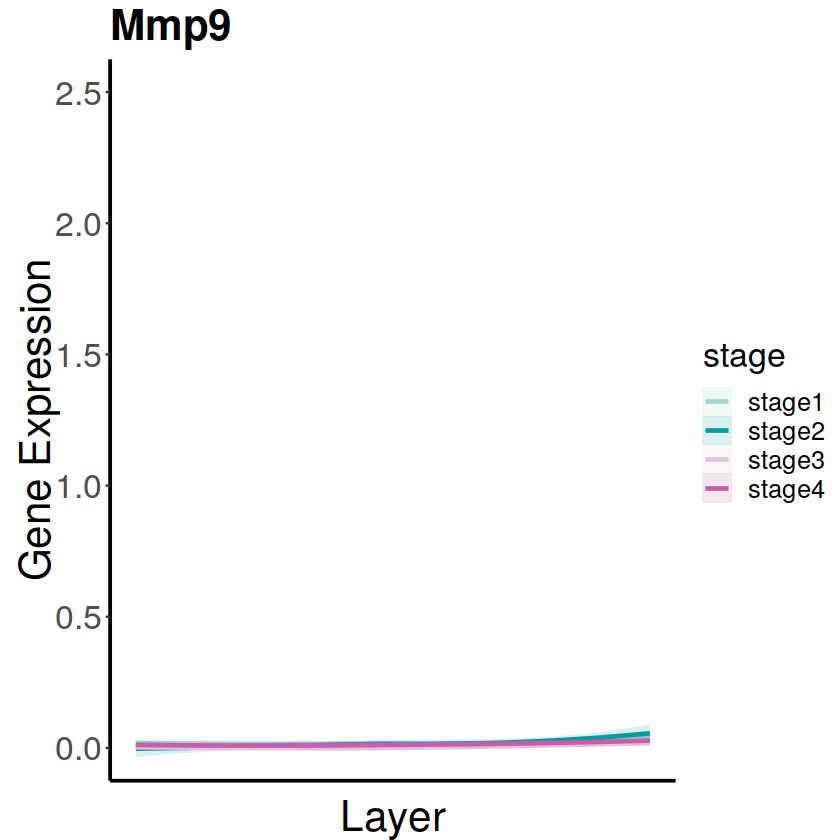

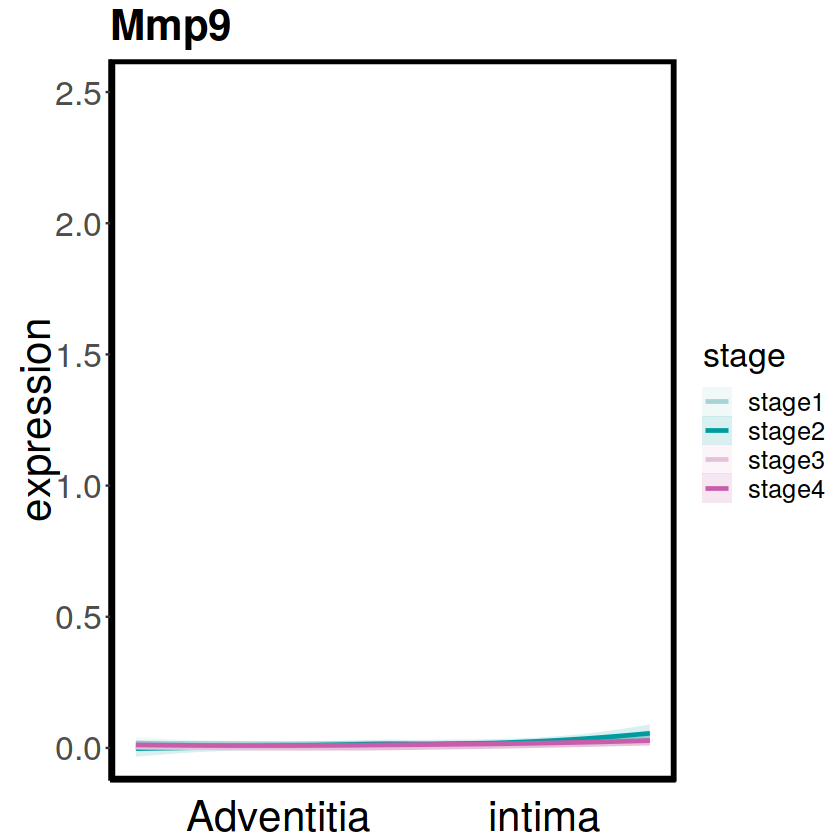

In [26]:
p <- ggplot(m,aes(x=layer,y = Mmp9,fill=stage,color=stage))+theme_classic ()+
labs(title = "Mmp9")+geom_smooth(method = "loess",span=1,se = T,level=0.90,alpha=0.15)+scale_color_manual(values = cols5)+scale_fill_manual(values = cols5)+
labs(x="Layer",y="Gene Expression")+theme(axis.text = element_text (size = 20))+#调整坐标轴字体大小
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+#调整xlab字体大小
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+#调整ylab字体大小
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+#调整坐标轴样式
    theme(legend.title = element_text(size=20),  # 调整图例标题的大小
          legend.text = element_text(size=15))+ theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank())+coord_cartesian(ylim = c(0, 2.5))
p
p3 <- p+labs(x="Adventitia          intima",y="expression")+theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))
ggsave("update_S5_Mmp9.pdf",p3,width = 6.6,height = 6)
p3

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


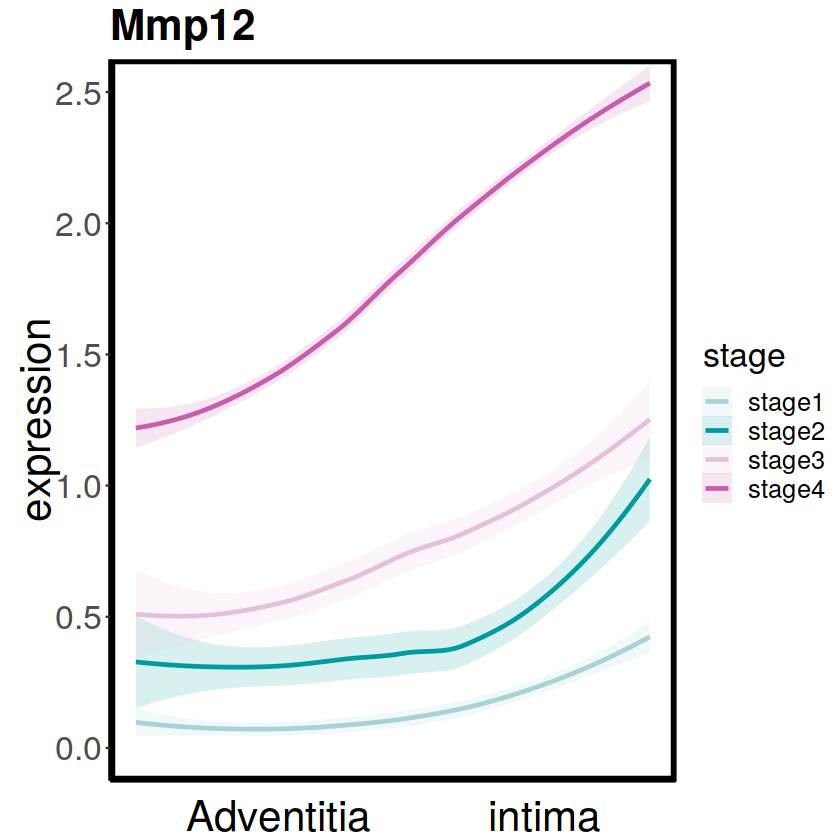

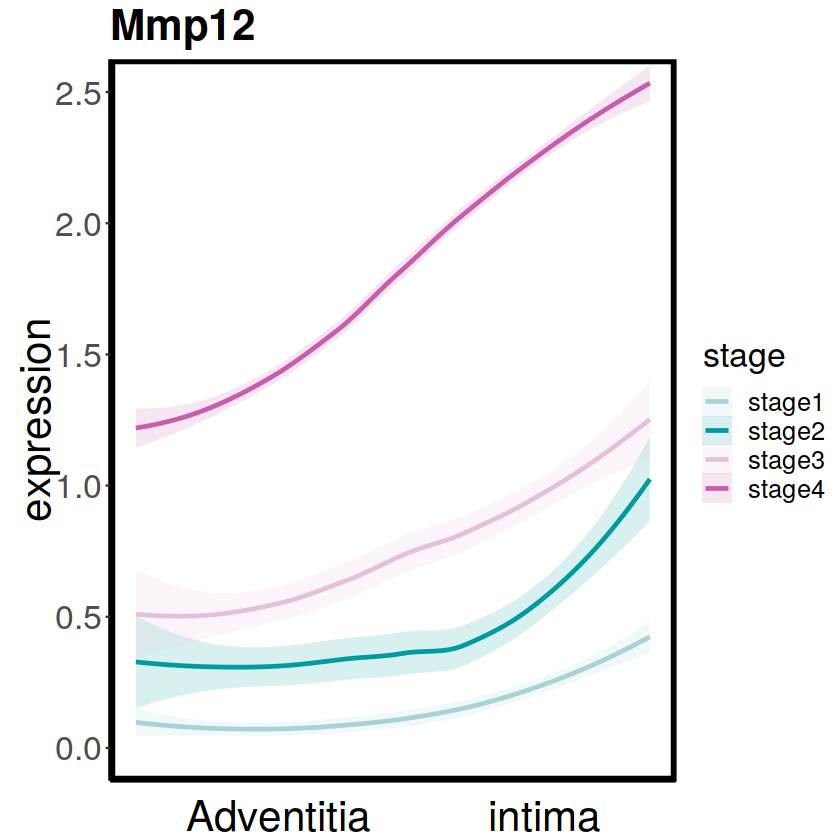

In [128]:
p2
p+labs(x="Adventitia          intima",y="expression")+theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))

In [ ]:
color <- c("Macrophage"='#df65b0',"Modulated_SMC"="#A1CFFA",
           "SMC"='#1f78b4',"EC"='#238b45',"Fibroblast"="#8b4a4b","Immune"='#ce1256')